# **체지방률 예측 회귀 모델 (Body Fat Percentage Regression Analysis)**
---

### <분석 목적>
다양한 신체 측정치를 사용하여 (예측) **체지방률(Body Fat Percentage)을 예측**하고,           
개인의 (해석) **체지방률에 영향을 주는 요소를 파악**할 수 있는 회귀모델을 개발하는 것

---

## 1. 데이터 살피기

In [1]:
import pandas as pd
df= pd.read_csv("bodyfat.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [2]:
df.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


---

## 2. 데이터 탐색(EDA)

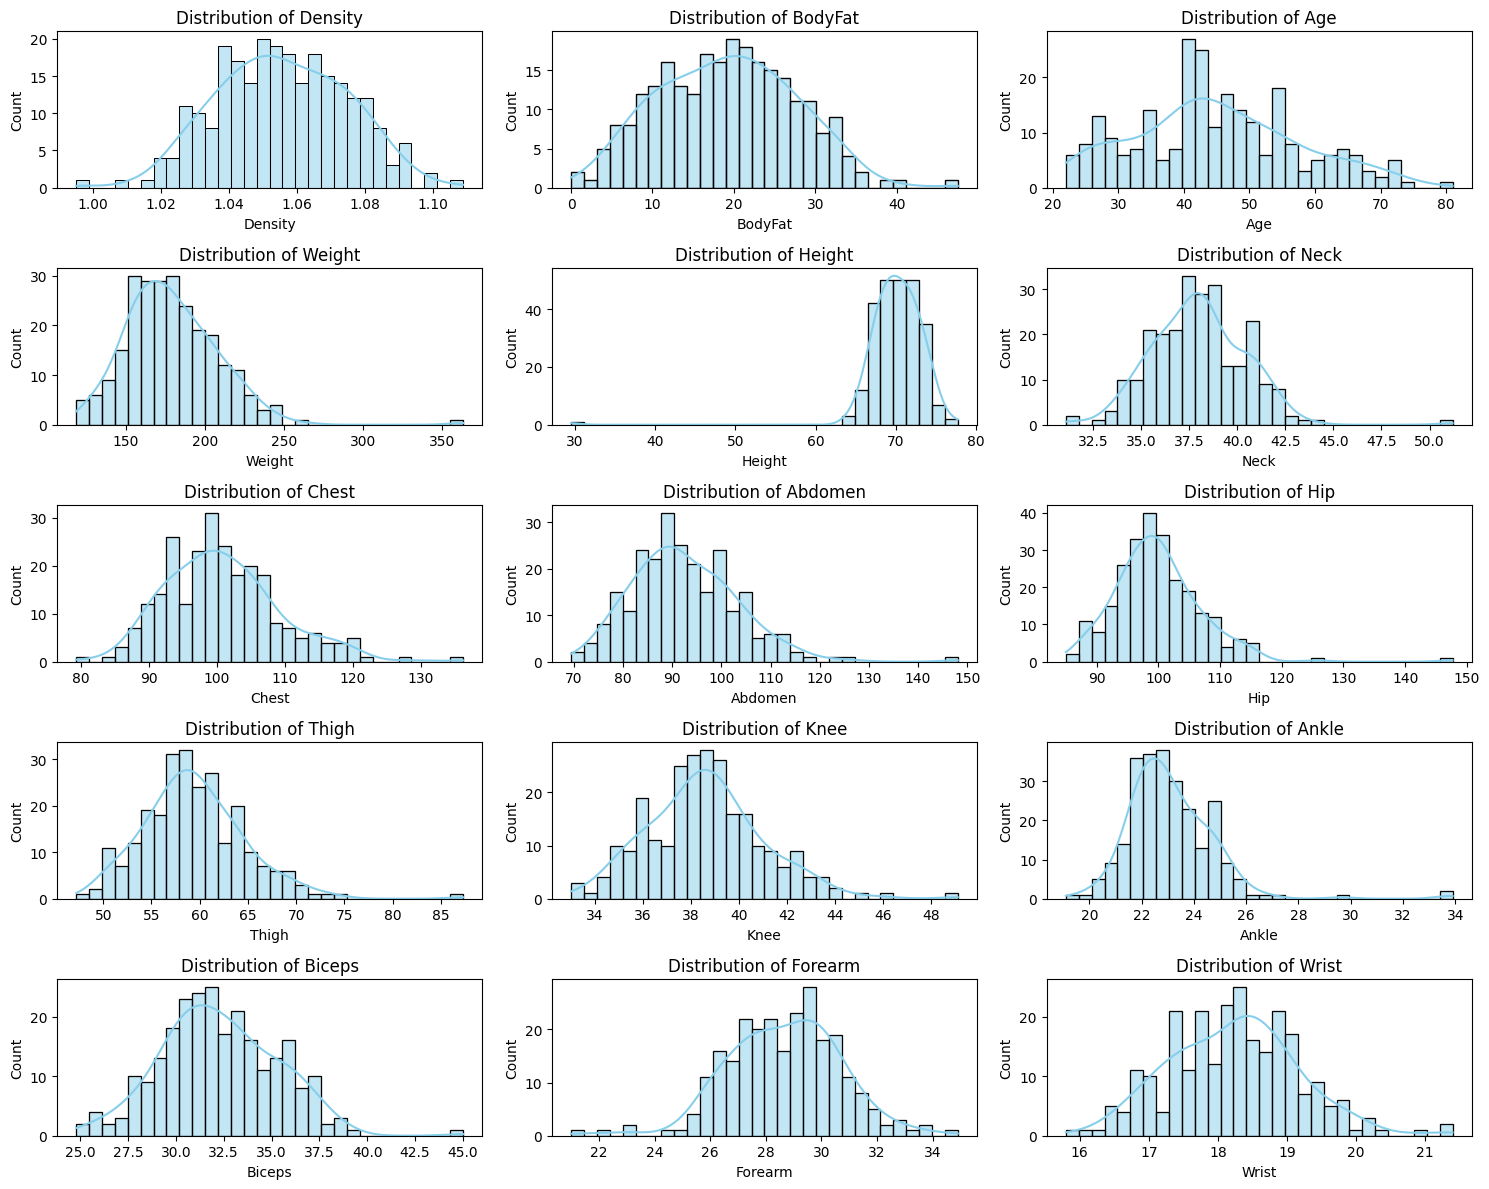

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import math


n_cols = len(df.columns)


n_rows = math.ceil(n_cols / 3) 

plt.figure(figsize=(15, 12))

for i, col in enumerate(df.columns, 1):
    plt.subplot(n_rows, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color="skyblue")
    plt.title(f"Distribution of {col}", fontsize=12)
    plt.tight_layout()

plt.show()


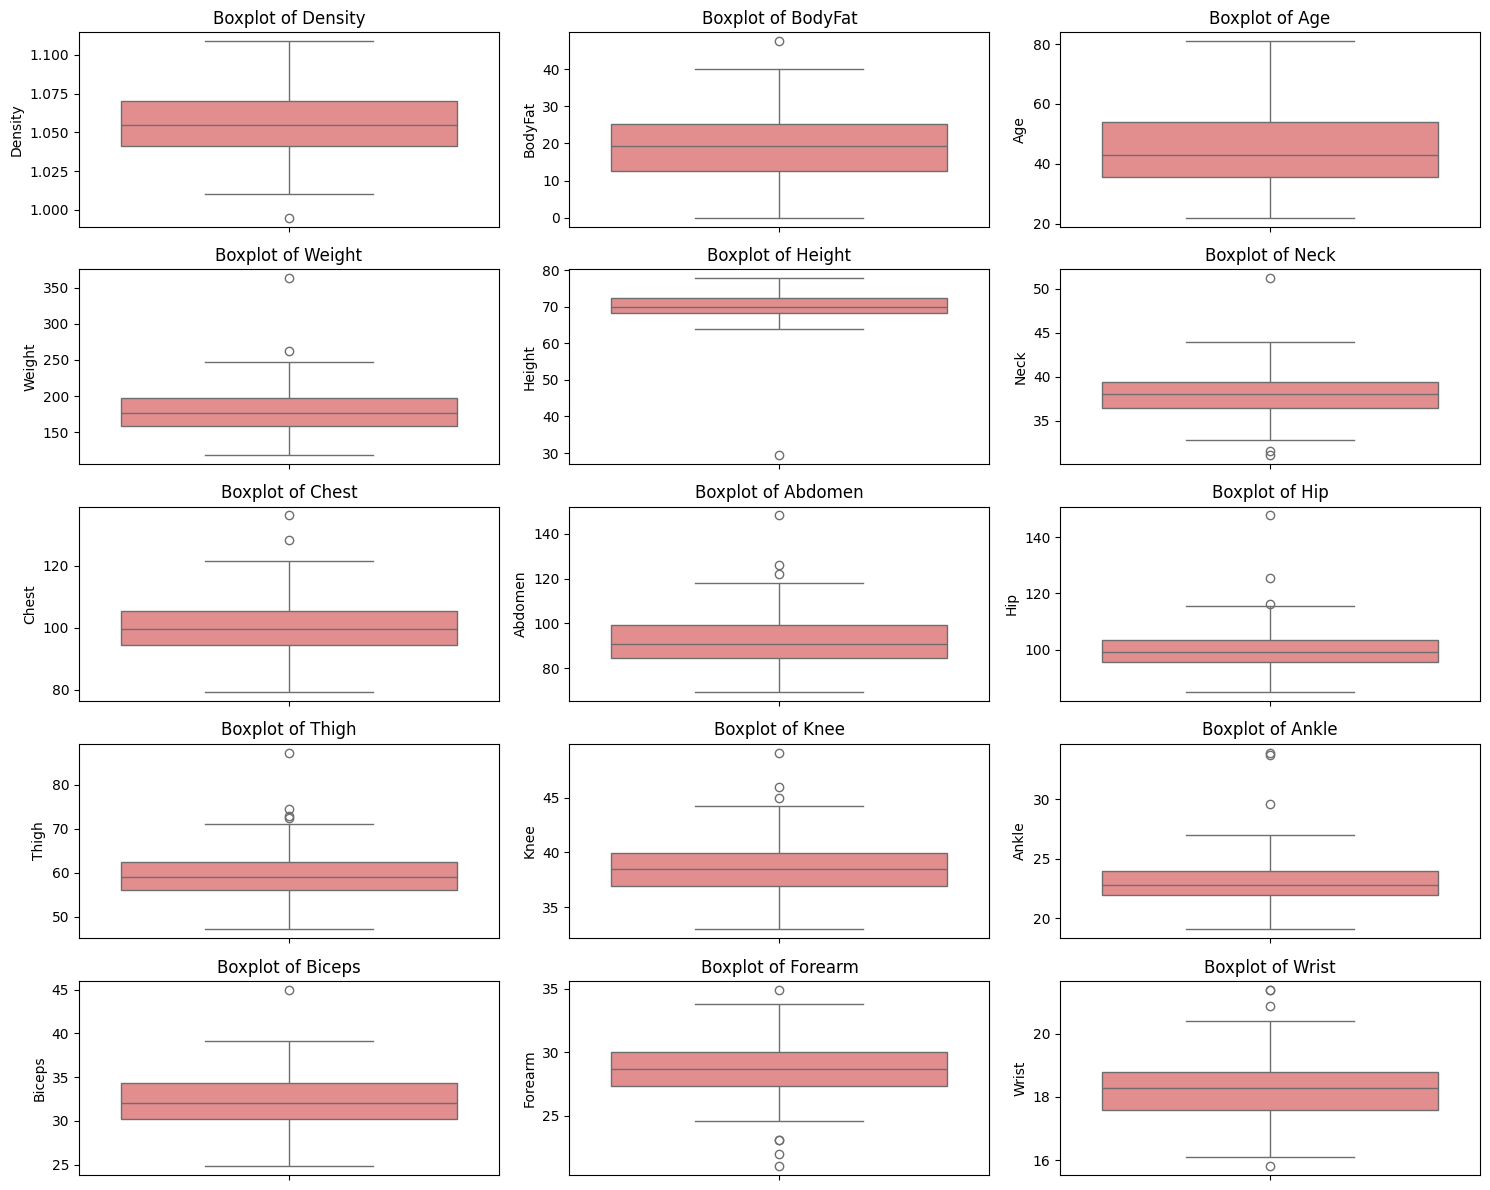

In [4]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(df.columns, 1):
    plt.subplot(n_rows, 3, i)
    sns.boxplot(y=df[col], color="lightcoral")
    plt.title(f"Boxplot of {col}", fontsize=12)
    plt.tight_layout()
plt.show()

In [5]:
# 불가능한 값 제거
df = df[df["BodyFat"] > 1]           
df = df[df["Density"] > 1.0]        
df = df[df["Height"] > 55]           
#df = df[df["Weight"] < 300]          
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 248 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  248 non-null    float64
 1   BodyFat  248 non-null    float64
 2   Age      248 non-null    int64  
 3   Weight   248 non-null    float64
 4   Height   248 non-null    float64
 5   Neck     248 non-null    float64
 6   Chest    248 non-null    float64
 7   Abdomen  248 non-null    float64
 8   Hip      248 non-null    float64
 9   Thigh    248 non-null    float64
 10  Knee     248 non-null    float64
 11  Ankle    248 non-null    float64
 12  Biceps   248 non-null    float64
 13  Forearm  248 non-null    float64
 14  Wrist    248 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 31.0 KB


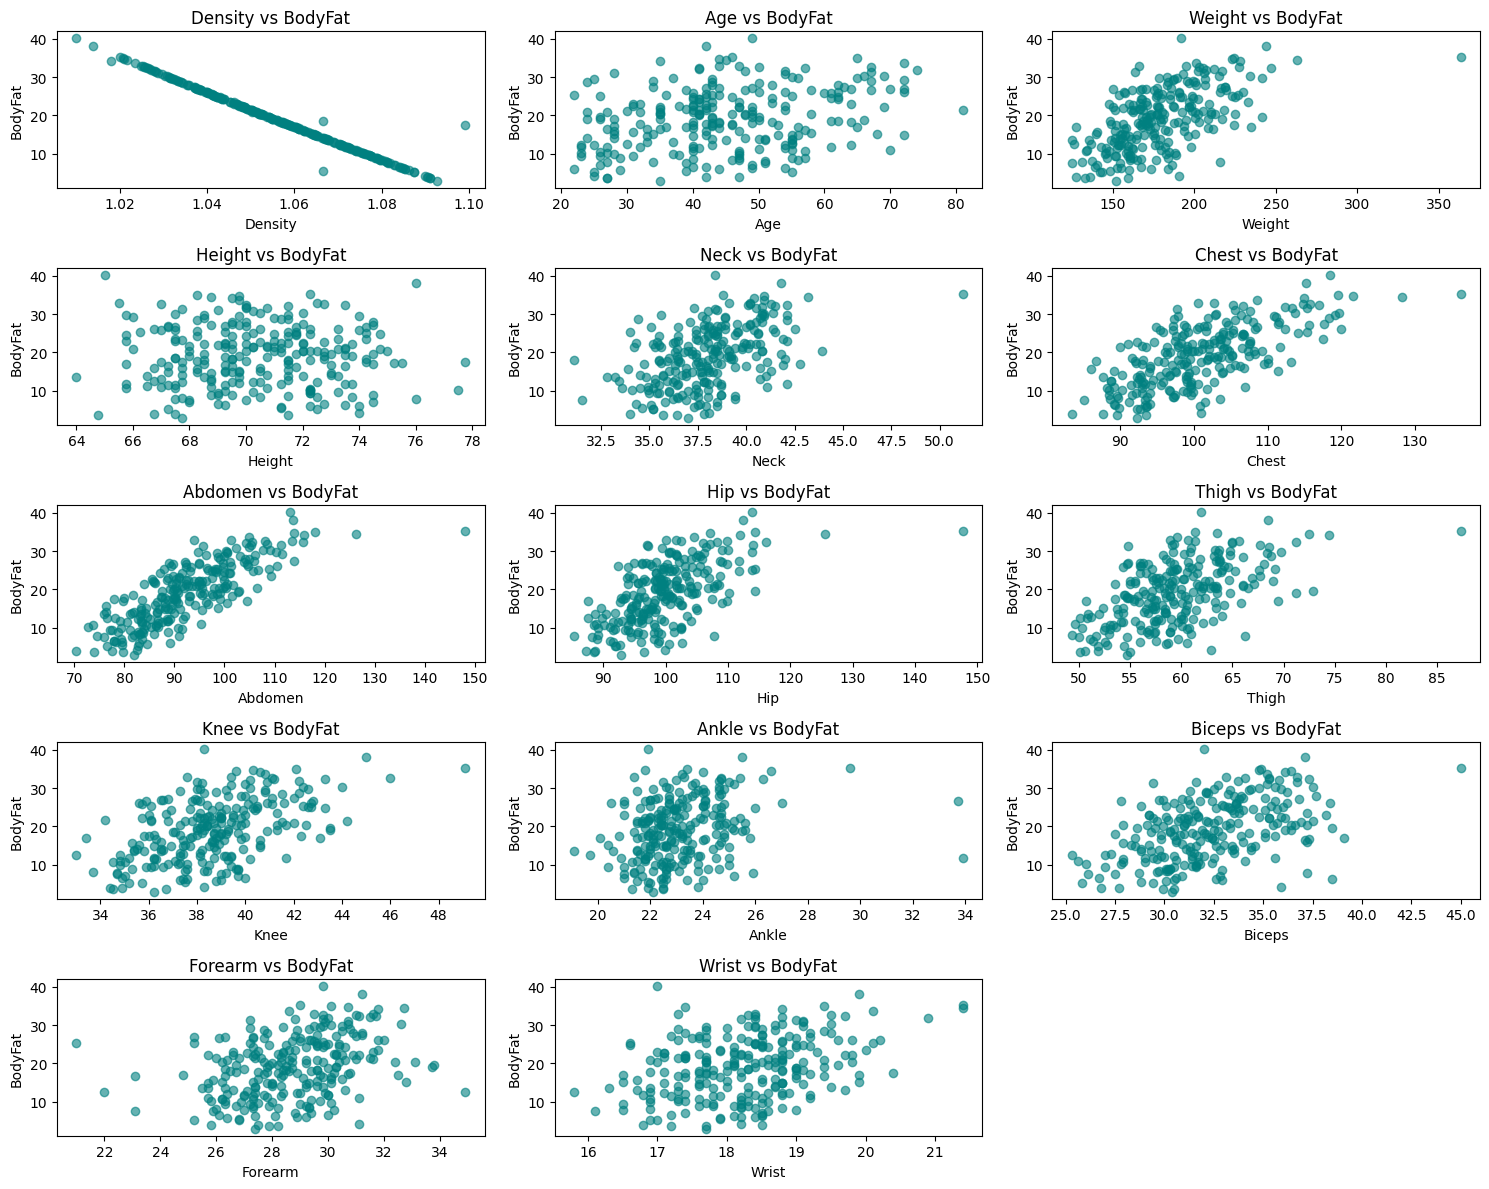

In [6]:
import math


features = [col for col in df.columns if col not in ["BodyFat"]]

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

plt.figure(figsize=(15, 12))

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.scatter(df[col], df["BodyFat"], alpha=0.6, color="teal")
    plt.xlabel(col)
    plt.ylabel("BodyFat")
    plt.title(f"{col} vs BodyFat")
    plt.tight_layout()

plt.show()

In [7]:
df = df.drop(columns=['Density'])


In [8]:
corr = df.corr()
print(corr["BodyFat"].sort_values(ascending=False))


BodyFat    1.000000
Abdomen    0.799646
Chest      0.686149
Hip        0.601166
Weight     0.594615
Thigh      0.541687
Knee       0.509576
Neck       0.477135
Biceps     0.476101
Forearm    0.349350
Wrist      0.341634
Age        0.289878
Ankle      0.252632
Height    -0.015940
Name: BodyFat, dtype: float64


In [9]:
df = df.drop(columns=['Height'])

In [10]:
df = df.reset_index(drop=True)
df

,BodyFat,Age,Weight,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.3,23,154.25,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.1,22,173.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.3,22,154.00,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.4,26,184.75,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.7,24,184.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,11.0,70,134.25,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5
244,33.6,72,201.00,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1
245,29.3,72,186.75,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0
246,26.0,72,190.75,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8


In [11]:
df_original=df

---

### <데이터 탐색 (EDA)>         
- 상자 그림: 이상치 확인(불가능한 값 제거)            
- 산점도: density는 bodyfat과 정확히 반비례(분석에 제외)            
- 상관계수: height-> 매우 낮음(분석에 제외)                                                                                          


---

## 3. 해석 모델

 **전략:**            
  다중공선성을 줄이기 위해 중요한 변수만 남기고, OLS 진행하여 반응변수에 가장 영향을 많이 미치는 요소 파악하기

### 3.1 회귀 적합

In [12]:
df = df_original.copy()

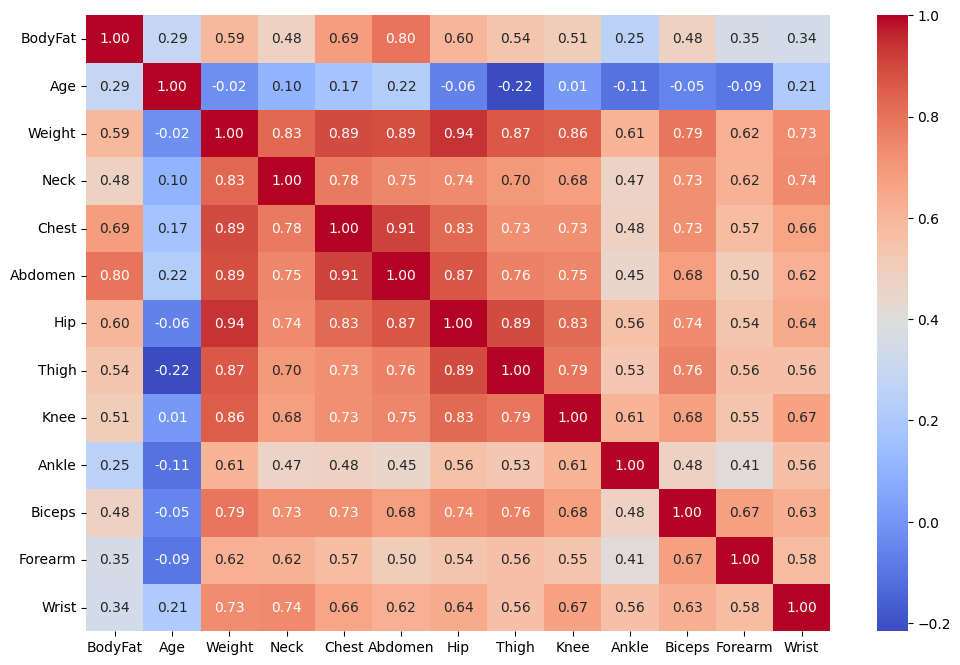

In [13]:
#다중공선성 살피기
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


In [14]:
import statsmodels.api as sm
from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=['BodyFat'])
X_vif = add_constant(X)

vif = pd.DataFrame()
vif["features"] = X_vif.columns
vif["VIF Factor"] = [variance_inflation_factor(X_vif.values,i) for i in range(X_vif.shape[1])]

vif["VIF Factor"] = vif["VIF Factor"].round(1)

print(vif)

   features  VIF Factor
0     const      2698.2
1       Age         2.3
2    Weight        26.0
3      Neck         4.2
4     Chest         8.8
5   Abdomen        11.2
6       Hip        13.6
7     Thigh         7.3
8      Knee         4.5
9     Ankle         1.9
10   Biceps         3.5
11  Forearm         2.1
12    Wrist         3.3


In [15]:
df = df.drop(columns=['Weight'])

In [16]:
import statsmodels.api as sm
from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=['BodyFat'])
X_vif = add_constant(X)

vif = pd.DataFrame()
vif["features"] = X_vif.columns
vif["VIF Factor"] = [variance_inflation_factor(X_vif.values,i) for i in range(X_vif.shape[1])]

vif["VIF Factor"] = vif["VIF Factor"].round(1)

print(vif)
#다중공선성 완화됨

   features  VIF Factor
0     const       632.5
1       Age         2.1
2      Neck         3.8
3     Chest         7.6
4   Abdomen        10.9
5       Hip        10.2
6     Thigh         7.2
7      Knee         4.1
8     Ankle         1.8
9    Biceps         3.4
10  Forearm         2.1
11    Wrist         3.2


In [17]:
from sklearn.linear_model import LinearRegression
X = df.drop(['BodyFat'], axis=1)
y = df[['BodyFat']]

model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred = model.predict(X)

coef = model.coef_
intercept = model.intercept_

print(coef)
print(intercept)

[[ 0.08213048 -0.60501697 -0.08201445  0.91197817 -0.36034082  0.26048436
  -0.10165674  0.08142969  0.10949283  0.43667541 -1.83457638]]
[2.27218793]


In [19]:
import statsmodels.api as sm

X_const = sm.add_constant(X)
model_sm = sm.OLS(y, X_const).fit()
y_pred = model_sm.predict(X_const)

print(model_sm.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                BodyFat   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     56.49
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           8.19e-60
Time:                        10:39:41   Log-Likelihood:                -707.68
No. Observations:                 248   AIC:                             1439.
Df Residuals:                     236   BIC:                             1482.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2722      6.873      0.331      0.7

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print('MSE: ',mse)
print('R2: ',r2)


MSE:  17.623407897709562
R2:  0.7247557364867747


### 3.2 가정 검정

1. 선형성

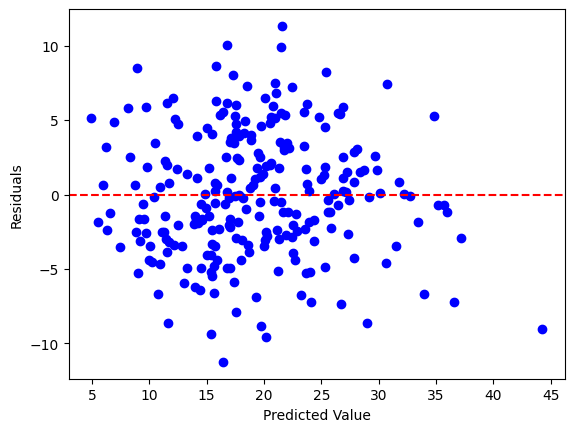

In [30]:
residuals = model_sm.resid
plt.scatter(y_pred, residuals, color = "blue")
plt.axhline(y=0, color = "red", linestyle = "--")
plt.xlabel('Predicted Value')
plt.ylabel('Residuals')
plt.show()

2. 독립성

In [31]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)



Durbin-Watson: 1.8505793009314793


3. 정규성

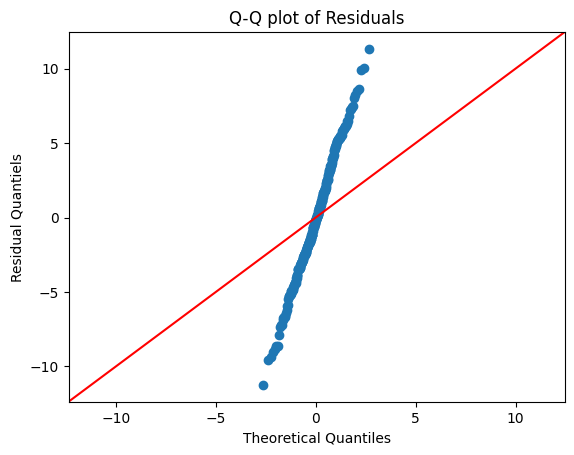

Shapiro-Wilk p-value: 0.6409286717154392


In [32]:

sm.qqplot(residuals, line = '45')
plt.title('Q-Q plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Residual Quantiels')
plt.show()  

import scipy.stats as stats

# Shapiro-Wilk test
stat, p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value:", p)


4. 등분산성

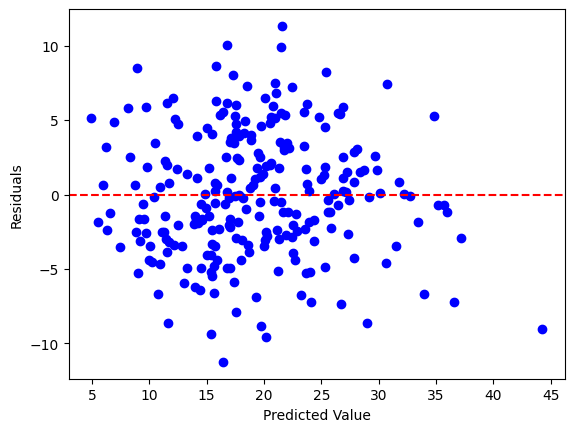

In [33]:
plt.scatter(y_pred, residuals, color = "blue")
plt.axhline(y=0, color = "red", linestyle = "--")
plt.xlabel('Predicted Value')
plt.ylabel('Residuals')
plt.show()

### 3.3 라쏘 (보완용)

In [34]:
df = df_original.copy()
df = df.drop(columns=['Weight'])
df

,BodyFat,Age,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,12.3,23,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.1,22,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,25.3,22,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.4,26,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,28.7,24,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7
...,...,...,...,...,...,...,...,...,...,...,...,...
243,11.0,70,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5
244,33.6,72,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1
245,29.3,72,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0
246,26.0,72,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8


In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

X = df.drop(['BodyFat'], axis=1)
y = df[['BodyFat']]

In [36]:
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [37]:
scaler = StandardScaler()
scaler.fit(train_X)
train_scaled = scaler.transform(train_X)
test_scaled = scaler.transform(test_X)



In [38]:
def lasso_optimal_alpha(alpha_list, train_X, train_y, test_X, test_y):

    train_score = list()
    test_score = list()

    for alpha in alpha_list:
        lasso = Lasso(alpha = alpha, max_iter = 50000) 
        lasso.fit(train_X, train_y)

        train_score.append(lasso.score(train_X, train_y))
        test_score.append(lasso.score(test_X, test_y))
    
    alpha_trace = pd.DataFrame({'alpha':alpha_list, 'Train_R2': train_score, 'Test_R2': test_score})

    return alpha_trace

In [39]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

lasso_alphas = lasso_optimal_alpha(alpha_list, train_scaled, train_y, test_scaled, test_y)
print(lasso_alphas)

     alpha  Train_R2   Test_R2
0    0.001  0.729705  0.650888
1    0.010  0.729593  0.646285
2    0.100  0.719736  0.603838
3    1.000  0.648891  0.568859
4   10.000  0.000000 -0.001346
5  100.000  0.000000 -0.001346


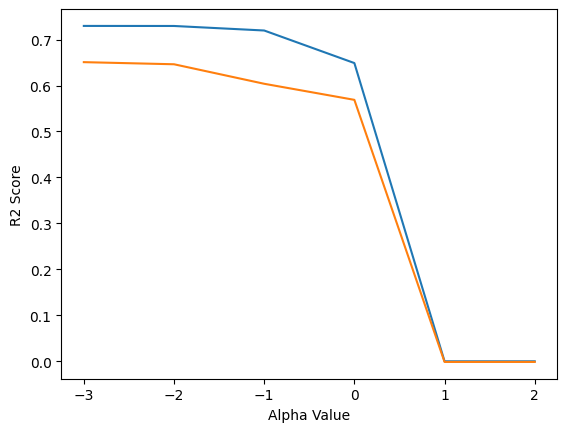

In [40]:
plt.plot(np.log10(alpha_list), lasso_alphas['Train_R2'])
plt.plot(np.log10(alpha_list), lasso_alphas['Test_R2'])
plt.xlabel('Alpha Value')
plt.ylabel('R2 Score')
plt.show()

In [41]:
lasso = Lasso(alpha = 0.1)
lasso.fit(train_scaled, train_y)

print('train R2: ', lasso.score(train_scaled, train_y))
print('test R2: ', lasso.score(test_scaled, test_y))
print('회귀계수: ', lasso.coef_)
print('절편: ', lasso.intercept_)

train R2:  0.7197355890732942
test R2:  0.6038380773576758
회귀계수:  [ 0.86435588 -0.18525181 -0.1779969   7.50786503 -0.          0.04063026
 -0.          0.09127819  0.14385626  0.         -1.89093112]
절편:  [19.07424242]


In [42]:
feature_names = X.columns

lasso_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Lasso Coefficient': lasso.coef_
})

print(lasso_coefficients)
print('---------------------------------------')
print('회귀 계수가 0인 변수의 개수: ', sum(lasso_coefficients['Lasso Coefficient'] == 0))


    Feature  Lasso Coefficient
0       Age           0.864356
1      Neck          -0.185252
2     Chest          -0.177997
3   Abdomen           7.507865
4       Hip          -0.000000
5     Thigh           0.040630
6      Knee          -0.000000
7     Ankle           0.091278
8    Biceps           0.143856
9   Forearm           0.000000
10    Wrist          -1.890931
---------------------------------------
회귀 계수가 0인 변수의 개수:  3


In [43]:
df = df.drop(columns=['Hip','Knee','Forearm'])

In [44]:
df

,BodyFat,Age,Neck,Chest,Abdomen,Thigh,Ankle,Biceps,Wrist
0,12.3,23,36.2,93.1,85.2,59.0,21.9,32.0,17.1
1,6.1,22,38.5,93.6,83.0,58.7,23.4,30.5,18.2
2,25.3,22,34.0,95.8,87.9,59.6,24.0,28.8,16.6
3,10.4,26,37.4,101.8,86.4,60.1,22.8,32.4,18.2
4,28.7,24,34.4,97.3,100.0,63.2,24.0,32.2,17.7
...,...,...,...,...,...,...,...,...,...
243,11.0,70,34.9,89.2,83.6,49.6,21.5,25.6,18.5
244,33.6,72,40.9,108.5,105.0,59.6,23.2,35.2,20.1
245,29.3,72,38.9,111.1,111.5,60.3,21.5,31.3,18.0
246,26.0,72,38.9,108.3,101.3,56.0,22.7,30.5,19.8


In [45]:
import statsmodels.api as sm
from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=['BodyFat'])
X_vif = add_constant(X)

vif = pd.DataFrame()
vif["features"] = X_vif.columns
vif["VIF Factor"] = [variance_inflation_factor(X_vif.values,i) for i in range(X_vif.shape[1])]

vif["VIF Factor"] = vif["VIF Factor"].round(1)

print(vif)
#다중공선성 완화됨

  features  VIF Factor
0    const       510.9
1      Age         1.9
2     Neck         3.7
3    Chest         7.4
4  Abdomen         8.8
5    Thigh         5.1
6    Ankle         1.7
7   Biceps         3.1
8    Wrist         2.9


---

### <해석 모델>

**(1) 다중공선성 여부 확인**
- 히트맵,VIF: 매우 강함                 
(Weight, Hip, Chest, Thigh → 서로 상관이 0.9 이상이므로 동시에 쓰기 어려울 것으로 예상)

**(2) 변수 선택/제거**
- 반응변수와 가장 유의한 관계를 가진 Abdomen 남기고, 상관성 높은 weight,hip변수 제거          
- 실제로 Abdomen과 Weight는 거의 같이 움직이므로 → 현실적으로 두 변수를 같이 분석하기 한계 있음       
                

**(3) 회귀 적합**
- 결정계수: 0.715 (71% 매우 높음)           
- F: 통계적 유의            
- abdomen,wrist,age,neck변수 가장 유의                   
- MSE: 18.248              
               

**(4) 가정 검정**
- 선형성: 예측값vs잔차 플롯 랜덤함
- 독립성: 더빈왓슨 1.91(2에 근사)
- 정규성: 그래프 살짝 벗어남 but shapiro-wilk 매우 유의(>0.05)
- 등분산성: 잔차 분산 일정

**(5) 라쏘 (보완용)**
- OLS만 하면 다중공선성이 여전히 높아서 해석력을 높이기 위해 라쏘 진행                 
- 훈련 데이터 설명력 72%, 테스트 데이터 예측력 60% (설명력 높음)          
- 복부 둘레, 손목, 나이, 목이 핵심 변수(ols와 같은 결과)           
- VIF 모두 10 미만(다중공선성 크게 문제 되지 않음)      
         
**(6) 해석하기**
- 체지방률과 가장 강하게 연관된 변수는 복부의 둘레         
- 손목,목은 음의 관계 가짐: 다른 변수가 다 똑같을 때, 손목/목 둘레가 큰 사람은 상대적으로 체지방률이 낮음(근육질 체형 가능성 있음)              
- 나이가 많을수록 체지방률 높아지는 경향 보임(실제로 나이가 들수록 내장 지방 증가함)               
- 다중공선성이 아직 존재하긴 함             


---

## 4. 예측 모델

**전략:**      
 과적합 방지를 위해 릿지로 제어 후, 평균제곱오차를 최대한 줄여 미래 값을 정확히 맞출 수 있는 모델 만들기


### 4.1 예측 전 모델 안정화 (릿지)

In [46]:
df = df_original.copy()

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

X = df.drop(['BodyFat'], axis=1)
y = df[['BodyFat']]

In [48]:
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
scaler.fit(train_X)
train_scaled = scaler.transform(train_X)
test_scaled = scaler.transform(test_X)


In [49]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(train_scaled, train_y)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [50]:
print(ridge.score(train_scaled, train_y))
print(ridge.score(test_scaled, test_y))

0.734465237326112
0.6604446218502018


In [51]:
def ridge_optimal_alpha(alpha_list, train_X, train_y, test_X, test_y):

    train_score = list()
    test_score = list()

    for alpha in alpha_list:
        ridge = Ridge(alpha = alpha)
        ridge.fit(train_X, train_y)

        train_score.append(ridge.score(train_X, train_y))
        test_score.append(ridge.score(test_X, test_y))
    
    r2_by_alpha = pd.DataFrame({'alpha':alpha_list, 'Train_R2': train_score, 'Test_R2': test_score})

    return r2_by_alpha

In [52]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]  #로그 값

ridge_alphas = ridge_optimal_alpha(alpha_list, train_scaled, train_y, test_scaled, test_y)

print(ridge_alphas)

     alpha  Train_R2   Test_R2
0    0.001  0.734870  0.663852
1    0.010  0.734870  0.663824
2    0.100  0.734866  0.663541
3    1.000  0.734465  0.660445
4   10.000  0.719352  0.626990
5  100.000  0.626188  0.535391


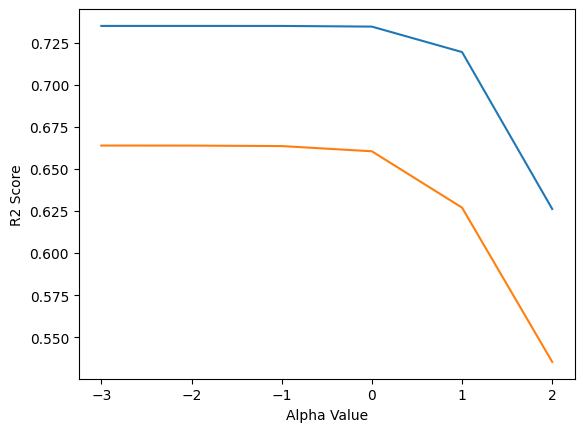

In [53]:
plt.plot(np.log10(alpha_list), ridge_alphas['Train_R2'])
plt.plot(np.log10(alpha_list), ridge_alphas['Test_R2'])
plt.xlabel('Alpha Value')
plt.ylabel('R2 Score')
plt.show()

In [54]:
ridge = Ridge(alpha = 0.1)
ridge.fit(train_scaled, train_y)

print(ridge.score(train_scaled, train_y))
print(ridge.score(test_scaled, test_y))

0.7348655855879089
0.663541181601184


In [55]:
print(ridge.coef_)
print(ridge.intercept_)

[ 0.76180597 -2.63296727 -0.31853568 -0.52135525  9.40535019 -0.4940692
  0.86287835 -0.02503442  0.55535652  0.61335662  0.28005822 -1.74136475]
[19.07424242]


In [ ]:
from sklearn.model_selection import GridSearchCV

alphas = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]} 

grid_cv = GridSearchCV(ridge, alphas)

grid_cv.fit(train_scaled, train_y)

opt_alpha = grid_cv.best_estimator_
print(opt_alpha, grid_cv.score(train_scaled, train_y))

Ridge(alpha=0.001) 0.7348702221352716


In [ ]:
def ridge_trace(alpha_list, train_X, train_y):

    import pandas as pd
    coefficients = pd.DataFrame()

    for alpha in alpha_list:
        ridge = Ridge(alpha = alpha)
        ridge.fit(train_X, train_y)

        
        coef_df = pd.DataFrame([ridge.coef_])  

        coefficients = pd.concat([coefficients, coef_df], ignore_index=True)
    
    coefficients.insert(0, 'Alpha', alpha_list)

    return coefficients

In [58]:
alpha_list = [0.01, 0.1, 1, 10, 100, 1000]

ridges = ridge_trace(alpha_list, train_scaled, train_y)

print(ridges)


     Alpha         0         1         2         3         4         5  \
0     0.01  0.751998 -2.663599 -0.317591 -0.538006  9.453242 -0.503480   
1     0.10  0.761806 -2.632967 -0.318536 -0.521355  9.405350 -0.494069   
2     1.00  0.850650 -2.356471 -0.325371 -0.365984  8.960015 -0.402839   
3    10.00  1.264859 -0.987530 -0.300680  0.505261  6.387926  0.204566   
4   100.00  1.177479  0.378220  0.036815  1.125920  2.573116  0.827909   
5  1000.00  0.337123  0.371155  0.250436  0.508234  0.705282  0.437606   

          6         7         8         9        10        11  
0  0.858833 -0.022063  0.559264  0.617909  0.283212 -1.737354  
1  0.862878 -0.025034  0.555357  0.613357  0.280058 -1.741365  
2  0.897624 -0.049787  0.518859  0.572292  0.250116 -1.776081  
3  0.990187 -0.085570  0.291709  0.380383  0.055995 -1.847826  
4  0.707050  0.279054 -0.043771  0.285282 -0.126363 -0.907802  
5  0.348419  0.311530  0.112467  0.266037  0.142026  0.063780  


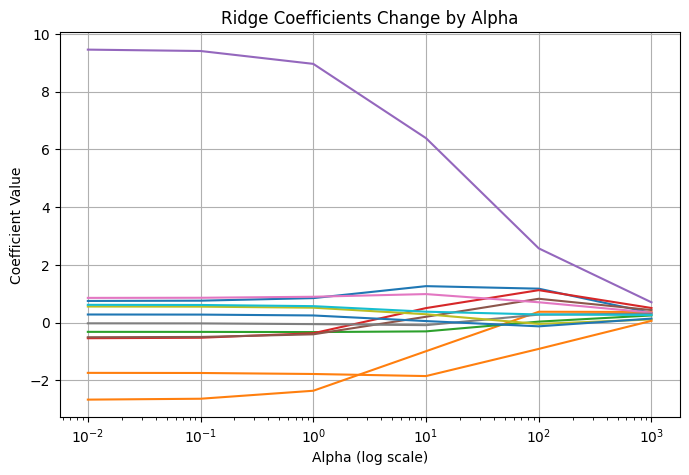

In [ ]:
import matplotlib.pyplot as plt

selected_features = ridges

# 그래프 그리기
plt.figure(figsize=(8, 5))

for column in selected_features.columns[1:]: 
    plt.plot(selected_features['Alpha'], selected_features[column], label=f'Feature {column}')

# 그래프 설정
plt.xscale('log') 
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficient Value")
plt.title("Ridge Coefficients Change by Alpha")
plt.grid(True)

plt.show()

In [60]:
y_pred_train = ridge.predict(train_scaled)
y_pred_test  = ridge.predict(test_scaled)

from sklearn.metrics import mean_squared_error
mse_train = mean_squared_error(train_y, y_pred_train)
mse_test  = mean_squared_error(test_y, y_pred_test)
print("Train MSE:", mse_train)
print("Test  MSE:", mse_test)


Train MSE: 17.08156402567118
Test  MSE: 20.99028754458197


In [61]:
from sklearn.metrics import r2_score

rmse_train = mse_train**0.5
rmse_test = mse_test**0.5
r2_train = r2_score(train_y, y_pred_train)
r2_test = r2_score(test_y, y_pred_test)

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)
print("Train R²:", r2_train)
print("Test R²:", r2_test)


Train RMSE: 4.132984880890708
Test RMSE: 4.581515856633257
Train R²: 0.7348655855879089
Test R²: 0.663541181601184


---

### <예측 모델>

**(1) 릿지**
- 새로운 데이터를 예측했을 때 평균적으로 ±4.6% 정도 오차가 (좋은 예측력)
- 과적합 여부: Train vs Test 성능 차이가 거의 없음 (RMSE 4.13 ↔ 4.58, R² 0.735 ↔ 0.664)
- 과적합 없이 안정적인 모델

**(2) 해석하기**     
- 새로운 데이터에 대해 약 66% 설명력 확보
- 교차검증 결과 알파=0.001이 최적(강한 규제 필요 없음) 


---

### <인사이트 정리> 

**누구에게:**      
- 헬스케어 서비스에서 ‘노인 대상 프로그램’ 제공


**어떤 가치를:**  
- 고가의 인바디 장비없이 간편한 서비스로 체지방률 추정 및 질환 예방
- 지속적인 데이터 저장 및 변화 추적으로 꾸준한 관리 받을 수 있음(건강 리스크 조기 발견)
- 이해하기 쉽게 체지방률 추세 그래프와 맞춤형 피드백 제공

**어떻게:**  
- 보건소에서 지원 받은 주기적 신체 측정(특히 복부둘레) 기록을 저장.입력
- 예상 체지방률 및 건강 리포트 제공
- 가족,의료진과 공유 가능한 서비스
   

**어떤 가격으로:**   
- 보건소에서 연계되는 헬스케어 서비스 패키지로 제공(앱,간단 코칭)

**얻는 방법:** 
- 앱 다운(B2C)
- 보건소와 제휴하여 공공보건 프로그램 내 서비스로 도입(B2B)
